<a href="https://colab.research.google.com/github/AnanyaUp/ANN-Deep-Learning/blob/main/Vision_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from transformers import ViTModel, ViTConfig
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
num_classes = 10
class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# Vision Transformer model
class CIFARViT(nn.Module):
    def __init__(self, num_classes=10):
        super(CIFARViT, self).__init__()
        config = ViTConfig(
            image_size=224,
            patch_size=16,
            num_channels=3,
            hidden_size=192,
            num_hidden_layers=6,
            num_attention_heads=6,
            intermediate_size=768,
            num_labels=num_classes
        )
        self.vit = ViTModel(config)
        self.classifier = nn.Linear(config.hidden_size, num_classes)

    def forward(self, x):
        outputs = self.vit(pixel_values=x)
        logits = self.classifier(outputs.last_hidden_state[:, 0, :])
        return logits

In [ ]:
# Loss and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FlowerViT(num_classes=num_classes).to(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [ ]:
# Training
def train(model, dataloader, criterion, optimizer, scheduler, epochs=10):
    train_losses, train_accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(dataloader, leave=True)
        loop.set_description(f'Epoch [{epoch+1}/{epochs}]')

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item())

        scheduler.step()
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

    return train_losses, train_accs



In [ ]:
# Visualization
def visualize_predictions(model, dataloader, num_images=5):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images[:num_images])
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img)
        plt.title(f'Pred: {class_names[preds[i]]}\nTrue: {class_names[labels[i]]}')
        plt.axis('off')
    plt.show()

In [ ]:
train_losses, train_accs = train(model, train_loader, criterion, optimizer, scheduler, epochs=10)

Epoch [1/10]: 100%|██████████| 782/782 [02:59<00:00,  4.36it/s, loss=1.52]


Epoch 1/10, Loss: 1.4899, Accuracy: 45.55%


Epoch [2/10]: 100%|██████████| 782/782 [02:59<00:00,  4.36it/s, loss=1.97]


Epoch 2/10, Loss: 1.3182, Accuracy: 52.25%


Epoch [3/10]: 100%|██████████| 782/782 [02:58<00:00,  4.38it/s, loss=1.48]


...

Epoch 8/10, Loss: 0.7220, Accuracy: 74.54%


Epoch [9/10]: 100%|██████████| 782/782 [02:58<00:00,  4.37it/s, loss=0.795]


Epoch 9/10, Loss: 0.6523, Accuracy: 77.12%


Epoch [10/10]: 100%|██████████| 782/782 [02:58<00:00,  4.38it/s, loss=0.625]

Epoch 10/10, Loss: 0.6059, Accuracy: 78.84%


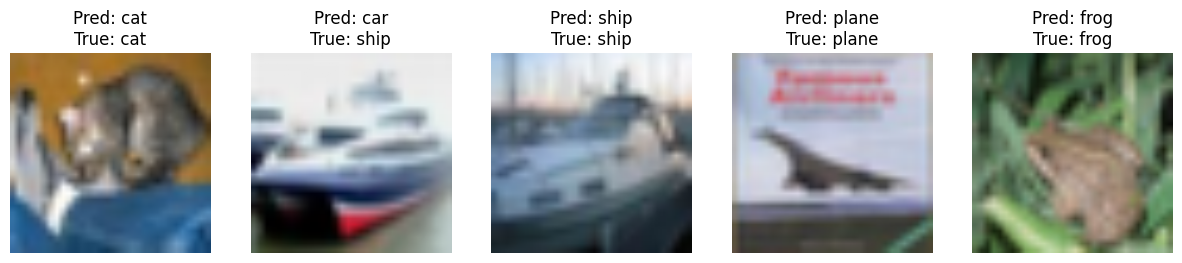

In [ ]:
visualize_predictions(model, test_loader, num_images=5)